# Coding Assignment 2

#### by Arnav Das (arnavmd2@uw.edu)

# Introduction to the Assignment  

In this assignment, you will build a model to **classify the sentiment of Yelp reviews**.

The **Yelp Reviews** dataset is a large collection of restaurant and business reviews written by users and annotated with **sentiment labels**.  
Each example contains a piece of review text along with a label indicating how positive or negative the reviewer’s experience was.

The goal is to **understand and categorize the sentiment expressed in each review** based solely on its text.

The labels correspond to different levels of sentiment:

#### 1-star — Strongly negative  
#### 2-star — Negative  
#### 3-star — Neutral  
#### 4-star — Positive  
#### 5-star — Strongly positive  

This dataset is widely used in **text classification and sentiment analysis**, making it a strong benchmark for evaluating how well models can interpret opinions, tone, and emotional content in written language.

# Part 1: Dataset Exploration (10 points)

Here we will do some quick sanity checks on the dataset, before we do any sort of training.

In [ ]:
from datasets import load_dataset

SEED = 42
N_TRAIN = 50_000
N_VAL   = 5_000
N_EVAL  = 500

ds = load_dataset("yelp_review_full")
train_full = ds["train"].shuffle(seed=SEED)
train = train_full.select(range(N_TRAIN))
val   = train_full.select(range(N_TRAIN, N_TRAIN + N_VAL))

test = ds["test"].shuffle(seed=SEED).select(range(N_EVAL))

README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

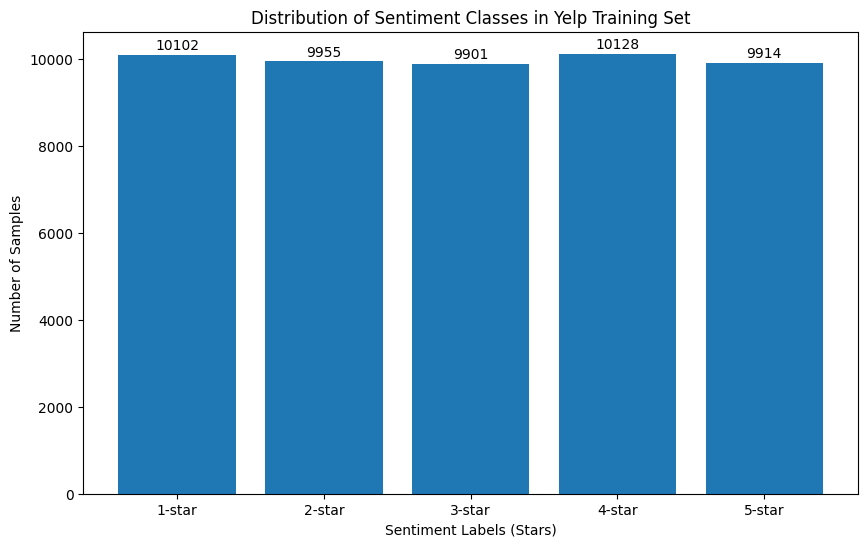

In [ ]:
#TODO Put your code here (2.5 pts).
###########################################################################
# Plot a bar graph, that shows how many samples there are each class
import matplotlib.pyplot as plt
import pandas as pd


train_labels = train['label']
label_series = pd.Series(train_labels)
counts = label_series.value_counts().sort_index()
class_names = ['1-star', '2-star', '3-star', '4-star', '5-star']
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, counts)

plt.title('Distribution of Sentiment Classes in Yelp Training Set')
plt.xlabel('Sentiment Labels (Stars)')
plt.ylabel('Number of Samples')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom')

plt.show()


###########################################################################

In [ ]:
import re
from collections import Counter
from tqdm import tqdm

NUM_CLASSES = 5
N = 5  # Try a few different values for this
MAX_SAMPLES = 10_000 # We only look at 10_000 samples for speed

# Each class label (0–4) gets its own Counter
ngram_counts = {i: Counter() for i in range(NUM_CLASSES)}


# Low level tokens like the ones BERT uses are not that useful, so we will construct coarser tokens for analysis
def simple_tokenize(text):
    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split(" ")


for i, example in tqdm(enumerate(train)):
    if MAX_SAMPLES and i >= MAX_SAMPLES:
        break

    text = example["text"]
    label = example["label"]

    tokens = simple_tokenize(text)
    pass
    #TODO: Put your code here (2.5 pts).
    for i in range(len(tokens) - N + 1):
        ngram = tuple(tokens[i : i + N])
        ngram_counts[label][ngram] += 1

    ###########################################################################
    #   Build all N-grams from `tokens` and count them
    #   in `ngram_counts[label]`
    #
    #   An N-gram is a tuple of N consecutive tokens.
    #
    #   Example (N=3):
    #     tokens = ["this","place","is","really","good"]
    #     trigrams = [
    #        ("this","place","is"),
    #        ("place","is","really"),
    #        ("is","really","good")
    #     ]
    # --------------------------------------------------
    ###########################################################################



# Extract top 5 n-grams per class
top_ngrams = {i: ngram_counts[i].most_common(5) for i in range(NUM_CLASSES)}

star_names = {
    0: "1-star",
    1: "2-star",
    2: "3-star",
    3: "4-star",
    4: "5-star",
}

for label in range(NUM_CLASSES):
    print("\n", star_names[label])
    for (ngram, count) in top_ngrams[label]:
        print(f"{' '.join(ngram):30s}  {count}")


10000it [00:08, 1133.87it/s]



 1-star
i will never go back            16
at the end of the               15
recommend this place to anyone  14
in the middle of the            12
i will not be returning         11

 2-star
do do do do do                  32
in the middle of the            19
wanted to like this place       13
get what you pay for            13
the best part of the            12

 3-star
in the middle of the            18
go out of my way                13
www yelp com biz photos         13
nothing to write home about     12
out of my way to                11

 4-star
is a great place to             17
just the right amount of        13
www yelp com biz photos         13
i will definitely be back       12
if you are looking for          12

 5-star
can't wait to go back           19
if you are looking for          14
is a great place to             14
is one of the best              13
you are looking for a           10


### TODO:
Please fill out the following questions:


**Q1 [2.5 points]: Is the dataset balanced?**

Yes, the dataset is balanced. As shown in the bar graph, each of the five sentiment classes has approximately 10,000 samples. This near-equal distribution ensures the model is trained fairly across all star ratings without class bias.

**Q2 [2.5 points]: Try a few different values for n and print out the top 5 n-grams for for each class. Which value of n gives you n-grams that are strongly tied to sentiment (e.g., “highly recommend this”, “worst place ever”)**

Higher values of n, such as n=4 and n=5, result in n-grams that are much more strongly tied to sentiment. n=2 capture common stop-word pairs (e.g., "of the", "in the") that appear frequently across all ratings and provide no sentiment value. n=4 or 5 captures complete expressions and specific feedback such as "i will never go back" or "i will not be" for 1-star reviews and "nothing to write home about" for neutral 3-star reviews and "one of the best" or "is a great place to" for 5-star reviews. These longer sequences provide the necessary context to distinguish between strongly negative, neutral, and strongly positive experiences.

# Part 2: GPT 4.1-Nano Zero-Shot Performance (20 points)

In this section, we evaluate GPT-4.1-nano as a zero-shot text classifier.
Zero-shot means the model is not trained on our dataset. Instead, we give it instructions in natural language and ask it to predict a label directly.

We will provide GPT with a prompt that describes the task (e.g., predicting a 1–5 star rating from a review) and pass in each test example. The model should output a single label based only on its pretrained knowledge.



In [ ]:
import os, json, time, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, accuracy_score

from openai import OpenAI
from google.colab import userdata


MODEL = "gpt-4.1-nano"
TEMPERATURE = 0.0
SLEEP_S = 0.0  # set to 0.05 if you hit rate limits
NUM_RETRIES = 5

API_KEY= userdata.get('open_ai_key')
client = OpenAI(api_key=API_KEY)


def gpt_predict_label(review_text: str) -> int:
    #TODO: Write a prompt that asks GPT to label a sample (5 points)
    ###########################################################################
    system = """
    You are an expert sentiment analyzer. Your task is to classify Yelp reviews into a 5-star rating scale.
    The labels are defined as follows:
    0: 1-star (Strongly negative)
    1: 2-star (Negative)
    2: 3-star (Neutral)
    3: 4-star (Positive)
    4: 5-star (Strongly positive)

    Respond with ONLY the integer (0, 1, 2, 3, or 4). Do not include any explanation.
    """
    user = f"Review Text: {review_text}\nLabel:"
    ###########################################################################

    resp = client.responses.create(
        model=MODEL,
        input=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        temperature=TEMPERATURE,
    )

    raw = resp.output_text  # plain text output
    return extract_label(raw)

def extract_label(text: str) -> int:
    """
    Robustly extract a label in {0,1,2,3,4} from model output.
    """
    #TODO: Put your code here (5 points).
    ###########################################################################
    match = re.search(r'[0-4]', text)
    if match:
        return int(match.group())
    ###########################################################################
    return 0

GPT inference: gpt-4.1-nano: 100%|██████████| 500/500 [04:47<00:00,  1.74it/s]


gpt-4.1-nano | N=500 | accuracy=0.6080


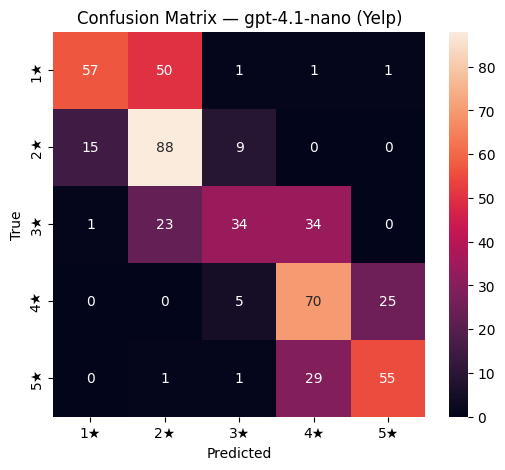

In [ ]:
# Get predictions for the full test set
y_true, y_pred = [], []

for ex in tqdm(test, desc=f"GPT inference: {MODEL}"):
    y_true.append(int(ex["label"]))

    retries = 0
    while retries < 5:
        try:
            y_pred.append(gpt_predict_label(ex["text"]))
            break
        except Exception as e:
            print("Failed to generate response", e)
            print("Retrying...")
            if SLEEP_S:
                time.sleep(SLEEP_S)

        if SLEEP_S:
            time.sleep(SLEEP_S)

acc = accuracy_score(y_true, y_pred)
print(f"{MODEL} | N={N_EVAL} | accuracy={acc:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["1★","2★","3★","4★","5★"],
    yticklabels=["1★","2★","3★","4★","5★"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {MODEL} (Yelp)")
plt.show()

### TODO:
Please fill out the following questions:


**Q3 (2.5 points): What accuracy does GPT attain on this dataset?**

GPT-4.1-nano attained an accuracy of 0.6080 (60.8%) on this Yelp test set. Because this is a random five-class classification task where a random baseline would be 20%, it indicates that the model has a strong understanding of sentiment without any specific training on this dataset.

**Q4 (2.5 points): What are the biggest failure modes of GPT?**

1. Adjacent Class Confusion: The model frequently confuses a rating with its immediate neighbor. For example, 50 1-star reviews were classified as 2-star, and 29 5-star reviews were classified as 4-star. This suggests the model struggles to distinguish between "strongly negative" and "negative" or "strongly positive" and "positive".

2. 3-star Ambiguity: The 3-star category had the lowest number of correct predictions (34). It was frequently misclassified as either 2-star (23 times) or 4-star (34 times), showing that the model finds "middle-ground" or mixed sentiment reviews the most difficult to categorize.

**Q5 (5 points): What are some ways to improve GPT performance on this dataset?**

1. Step-by-Step Reasoning: From previous lab, ask the model to "think step-by-step." would result in better performance. Forcing the model to list positive and negative aspects of the review before deciding on a final integer, it is more likely to handle complex or 3-star (neutral) reviews accurately.

2. Few-shot Prompting: Instead of zero-shot, provide the model with 2-3 examples for each star rating in the prompt. This would help the model understand more about sentiment and better match the specific labeling style of the Yelp dataset.

3. Restrict Class Definitions: Enhance the system prompt with specific criteria for each star level (e.g., "Assign 2 stars if the user mentioned they might return but were disappointed" or "Assign 1 star for an absolute terrible").

# Part 3: BERT-Based Classification (50 points)

Now we use BERT as a feature extractor for classification.
We keep BERT frozen and train a small neural network on top of it to predict the labels.

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from torch.optim import AdamW
from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# Function for tokenizing text
def manual_encode(text, max_length=512):
    """
    Encode a single Yelp review for BERT.
    Format: [CLS] text [SEP]
    """

    # Tokenize the text, and pad to max_length for collation
    tokens = tokenizer.tokenize(text)
    max_text_len = max_length - 2
    tokens = tokens[:max_text_len]
    tokens = [tokenizer.cls_token] + tokens + [tokenizer.sep_token]
    input_ids = tokenizer.convert_tokens_to_ids(tokens)
    attention_mask = [1] * len(input_ids)

    # Pad to max_length
    padding_length = max_length - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * padding_length
    attention_mask += [0] * padding_length

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }


In [ ]:
def update_dataset(example):
    return manual_encode(example["text"])

train = train.map(update_dataset)
val  = val.map(update_dataset)
test  = test.map(update_dataset)


train = train.remove_columns(["text"])
val = val.remove_columns(["text"])
test  = test.remove_columns(["text"])

train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val, batch_size=32)
test_loader  = DataLoader(test, batch_size=32)

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
import copy
import torch

@torch.no_grad()
def compute_embeddings(bert_model, loader, device, context_rep="cls"):
    bert_model.eval()
    all_embs = []
    all_labels = []

    for batch in tqdm(loader, desc=f"Embedding ({context_rep})"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state  # (B, T, H)

        if context_rep == "cls":
            #TODO Put your code here (5 points).
            ###########################################################################
            # last_hidden_state: (B, T, H); take [CLS] token at position 0
            emb = last_hidden[:, 0, :]
            ###########################################################################
            pass
        elif context_rep == "mean_pool":
            #TODO Put your code here (5 points).
            ###########################################################################
            # Mean pooling over tokens, ignoring padding via attention_mask
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
            sum_embeddings = torch.sum(last_hidden * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            emb = sum_embeddings / sum_mask
            ###########################################################################
            pass
        else:
            raise ValueError(f"Unknown context_rep: {context_rep}")

        all_embs.append(emb.cpu())
        all_labels.append(labels.cpu())

    X = torch.cat(all_embs, dim=0)      # (N, H)
    y = torch.cat(all_labels, dim=0)    # (N,)
    return X, y


class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_head(hidden_size, num_labels=5, classifier_type="linear"):
    if classifier_type == "linear":
        #TODO: Put your code here (5 points).
        # Add a linear layer which maps the pooled output of BERT to the number of desired classes (num_labels).
        # The linear layer essentially acts as a classifier on top of the BERT model, using the pooled representation of the input sequence to make class predictions.
        ###########################################################################
        clf = None
        clf = nn.Linear(hidden_size, num_labels)
        ###########################################################################
    elif classifier_type == "non-linear":
        #TODO: Put your code here (5 points).
        # Add two linear layers which map the pooled output of BERT to the number of desired classes (num_labels).
        # The first linear layer should be of size [hidden_size, 0.5*hidden_size]
        # The second linear layer should be of size [0.5*hidden_size, num_labels]
        # Add a RELU function between these two layers
        ###########################################################################
        clf = None
        mid_size = int(0.5 * hidden_size)
        clf = nn.Sequential(
            nn.Linear(hidden_size, mid_size),
            nn.ReLU(),
            nn.Linear(mid_size, num_labels)
        )
        ###########################################################################
    else:
        raise ValueError(f"Unknown classifier_type: {classifier_type}")


    return clf

def train_head(
    head,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=10,
    eval_every_epochs=1,
    eval_on_last_epoch=True,
):
    """
    Trains `head` and keeps the best-performing weights (by val_loss) in memory.
    Returns the head loaded with the best weights.

    Evaluation happens every `eval_every_epochs` epochs (at the end of the epoch),
    and optionally on the final epoch as well.
    """
    loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float("inf")
    best_state = None  # in-memory copy of best weights

    def run_validation():
        head.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for Xv, yv in val_loader:
                #TODO: Put your code here (5 points).
                # This code is to loop over all validation set embeddings and compute the loss and accuracy
                ###########################################################################
                Xv, yv = Xv.to(device), yv.to(device)

                outputs = head(Xv)

                batch_loss = loss_fn(outputs, yv)
                val_loss += batch_loss.item()

                preds = outputs.argmax(dim=1)
                correct += (preds == yv).sum().item()
                total += yv.size(0)
                ###########################################################################
                pass
        val_acc = correct/total

        return val_loss, val_acc


    for epoch in range(num_epochs):
        head.train()
        for X, y in tqdm(train_loader, desc=f"Head epoch {epoch+1}/{num_epochs}"):
            #TODO: Put your code here (10 points)
            # Add training logic here
            ###########################################################################
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            outputs = head(X)
            loss = loss_fn(outputs, y)

            loss.backward()

            optimizer.step()
            ###########################################################################
            pass

        should_eval = ((epoch + 1) % eval_every_epochs == 0) or (
            eval_on_last_epoch and (epoch + 1 == num_epochs)
        )
        if should_eval:
            val_loss, val_acc = run_validation()
            print(f"[epoch {epoch+1}] val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(head.state_dict())
                print("  -> new best head kept in memory")

    # Load best weights back into `head` before returning
    if best_state is not None:
        head.load_state_dict(best_state)

    return head

In [ ]:
# Function for evaluation and plotting confusion matrix (HEAD ONLY, EMBEDDING BATCHES ONLY)
def evaluate_and_plot(head, test_loader, device, classifier_type, context_rep):
    """
    Assumes:
      - test_loader yields batches of (X, y) from EmbeddingDataset
      - head(X) returns logits of shape (B, num_classes)
    """
    head.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device)

            logits = head(X)
            preds = logits.argmax(dim=1)

            y_true.append(y.detach().cpu().numpy())
            y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=["1★","2★","3★","4★","5★"],
        yticklabels=["1★","2★","3★","4★","5★"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix — {classifier_type} ({context_rep})")
    plt.show()

    accuracy = float((y_true == y_pred).mean()) if len(y_true) > 0 else 0.0
    print(f"classifier_type-{classifier_type} context_rep-{context_rep}")
    print(f"Accuracy: {accuracy:.4f}")

    return accuracy, cm

In [ ]:
import numpy as np
# 1) Load BERT once and freeze it
device = 'cuda:0'
bert = BertModel.from_pretrained("bert-base-uncased").to(device)
for p in bert.parameters():
    p.requires_grad_(False)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# 2) Precompute embeddings ONCE
CONTEXT_REP = 'cls' # 'cls, mean_pool'
X_train, y_train = compute_embeddings(bert, train_loader, device, context_rep=CONTEXT_REP)
X_val, y_val     = compute_embeddings(bert, val_loader, device, context_rep=CONTEXT_REP)
X_test, y_test   = compute_embeddings(bert, test_loader, device, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=164.1888 val_acc=0.5288
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=159.3040 val_acc=0.5430
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=154.6129 val_acc=0.5566
  -> new best head kept in memory


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=154.2552 val_acc=0.5596
  -> new best head kept in memory


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=154.6252 val_acc=0.5584


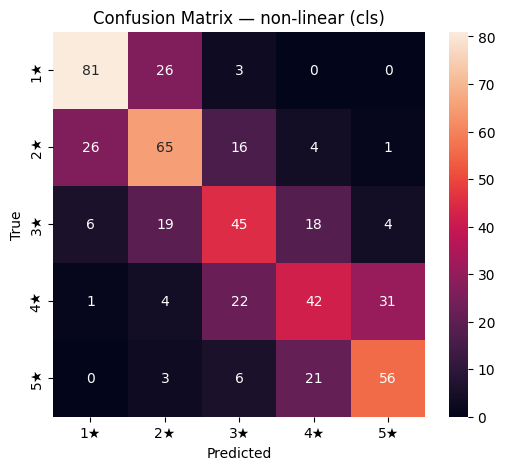

classifier_type-non-linear context_rep-cls
Accuracy: 0.5780


In [ ]:
# Hyperparameters
CLF_TYPE = 'non-linear'
LEARNING_RATE = 0.0005
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=160.4931 val_acc=0.5446
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=159.2954 val_acc=0.5432
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=157.7031 val_acc=0.5522


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=155.7824 val_acc=0.5632


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=155.9025 val_acc=0.5576


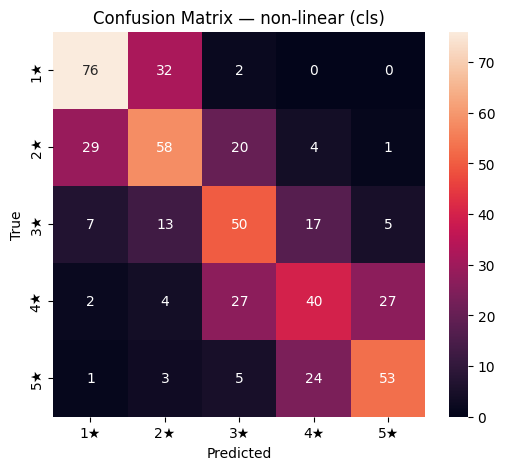

classifier_type-non-linear context_rep-cls
Accuracy: 0.5540


In [ ]:
# Hyperparameters
CLF_TYPE = 'non-linear'
LEARNING_RATE = 0.001
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=169.0186 val_acc=0.5286
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=163.8575 val_acc=0.5316
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=159.7054 val_acc=0.5432


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=161.5446 val_acc=0.5398


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=159.3379 val_acc=0.5480
  -> new best head kept in memory


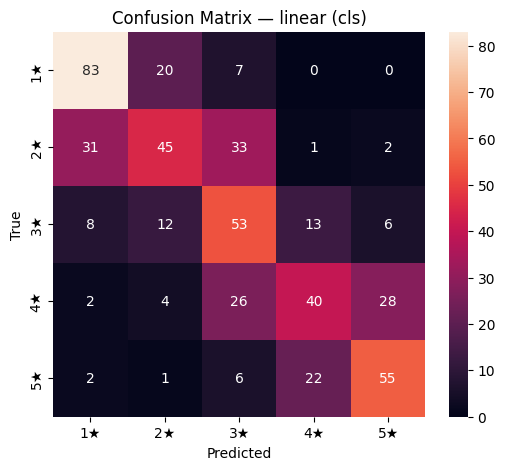

classifier_type-linear context_rep-cls
Accuracy: 0.5520


In [ ]:
# Hyperparameters
CLF_TYPE = 'linear'
LEARNING_RATE = 0.0005
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=165.6029 val_acc=0.5280
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=161.9594 val_acc=0.5442
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=158.3257 val_acc=0.5474
  -> new best head kept in memory


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=166.6456 val_acc=0.5302


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=158.7205 val_acc=0.5478


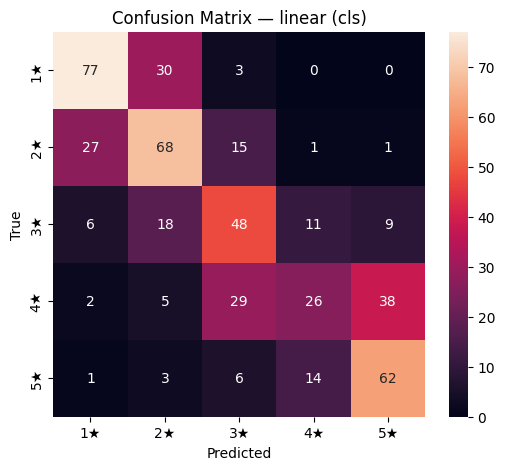

classifier_type-linear context_rep-cls
Accuracy: 0.5620


In [ ]:
# Hyperparameters
CLF_TYPE = 'linear'
LEARNING_RATE = 0.001
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

In [ ]:
# 2) Precompute embeddings ONCE
CONTEXT_REP = 'mean_pool' # 'cls, mean_pool'
X_train, y_train = compute_embeddings(bert, train_loader, device, context_rep=CONTEXT_REP)
X_val, y_val     = compute_embeddings(bert, val_loader, device, context_rep=CONTEXT_REP)
X_test, y_test   = compute_embeddings(bert, test_loader, device, context_rep=CONTEXT_REP)

Embedding (mean_pool):   0%|          | 0/1563 [00:00<?, ?it/s]

Embedding (mean_pool):   0%|          | 0/157 [00:00<?, ?it/s]

Embedding (mean_pool):   0%|          | 0/16 [00:00<?, ?it/s]

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=151.7098 val_acc=0.5692
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=159.0570 val_acc=0.5536


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=149.1758 val_acc=0.5754


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=150.5964 val_acc=0.5694


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=150.1439 val_acc=0.5658


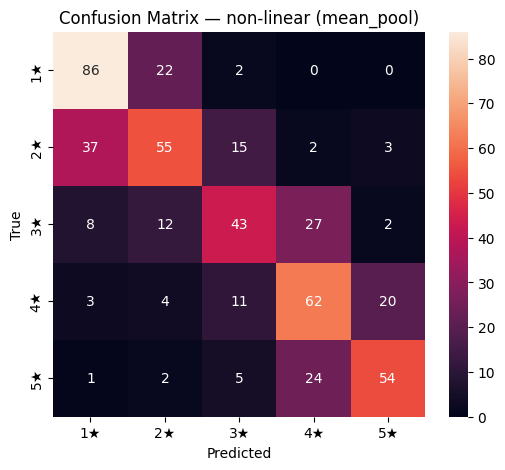

classifier_type-non-linear context_rep-mean_pool
Accuracy: 0.6000


In [ ]:
# Hyperparameters
CLF_TYPE = 'non-linear'
LEARNING_RATE = 0.001
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=153.9672 val_acc=0.5596
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=149.8912 val_acc=0.5758
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=151.4158 val_acc=0.5710


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=148.2549 val_acc=0.5814


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=152.5859 val_acc=0.5696


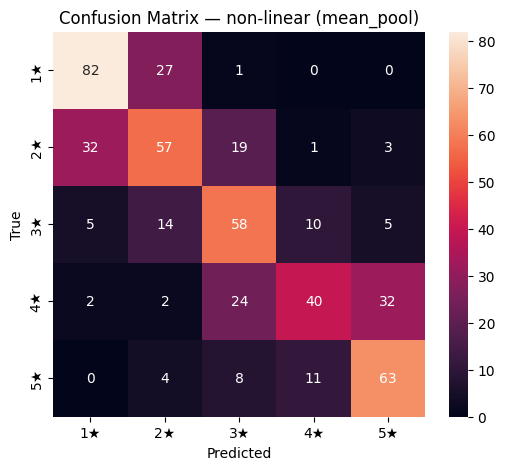

classifier_type-non-linear context_rep-mean_pool
Accuracy: 0.6000


In [ ]:
# Hyperparameters
CLF_TYPE = 'non-linear'
LEARNING_RATE = 0.0005
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=161.4191 val_acc=0.5452
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=157.7331 val_acc=0.5564
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=154.1425 val_acc=0.5680
  -> new best head kept in memory


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=154.2224 val_acc=0.5744


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=154.5528 val_acc=0.5642


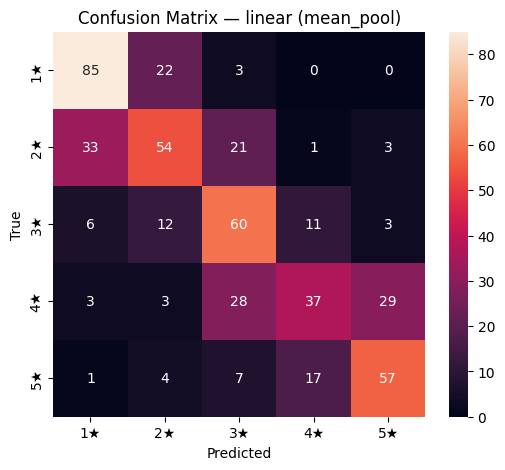

classifier_type-linear context_rep-mean_pool
Accuracy: 0.5860


In [ ]:
# Hyperparameters
CLF_TYPE = 'linear'
LEARNING_RATE = 0.001
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

Head epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 1] val_loss=167.3468 val_acc=0.5458
  -> new best head kept in memory


Head epoch 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 2] val_loss=160.6062 val_acc=0.5582
  -> new best head kept in memory


Head epoch 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...

[epoch 8] val_loss=155.0124 val_acc=0.5642
  -> new best head kept in memory


Head epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 9] val_loss=154.8760 val_acc=0.5656
  -> new best head kept in memory


Head epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

[epoch 10] val_loss=154.3711 val_acc=0.5706
  -> new best head kept in memory


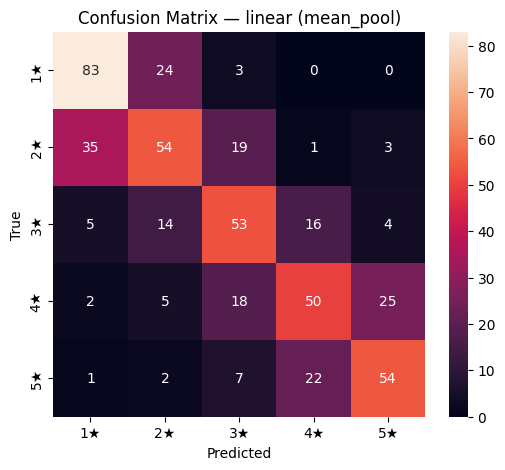

classifier_type-linear context_rep-mean_pool
Accuracy: 0.5880


In [ ]:
# Hyperparameters
CLF_TYPE = 'linear'
LEARNING_RATE = 0.0005
BATCH_SIZE = 32

# 3) Build embedding loaders (much faster)
train_emb_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_emb_loader   = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_emb_loader  = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# 4) Train a small head for many epochs cheaply
hidden_size = X_train.shape[1]
head = make_head(hidden_size, num_labels=5, classifier_type=CLF_TYPE).to(device)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE)

best_head = train_head(head, train_emb_loader, val_emb_loader, opt, device, num_epochs=10, eval_every_epochs=1)
ret = evaluate_and_plot(best_head, test_emb_loader, device, classifier_type=CLF_TYPE, context_rep=CONTEXT_REP)

### TODO:
Please fill out the following questions:


**Q6 (5 points): Test all configurations of BERT (both head types and context representation types) and fill out a table of results. For each configuration, find a learning rate that gives reasonable performance (you do not need to report every learning rate tried).**

Here is the summary of the performance for different BERT configurations. For each configuration, the learning rate that yielded the best performance is reported.

| Head Type | Context Representation | Learning Rate | Test Accuracy |
| :--- | :--- | :--- | :--- |
| Linear | CLS | 0.001 | 56.2% |
| Linear | mean_pool | 0.0005 | 58.8% |
| Non-linear | CLS | 0.0005 | 57.8% |
| Non-linear | mean_pool | 0.0005 | 60.2% |

Observations & Analysis:

1.  Context Representation (mean_pool vs. cls):
    * I observed that mean_pool outperforms the cls token representation in both linear and non-linear configurations.
    * For example, with the Non-linear head, Mean Pooling achieved 60.2 accuracy compared to 57.8% for the cls token. This suggests that averaging the embeddings of all tokens captures the semantic information of the full review text more effectively than relying solely on the single classification token.

2.  Head Type (Linear vs. Non-linear):
    * The Non-linear classifier generally performed better than the simple Linear head.
    * The best result was achieved using the Non-linear head (60.2%), which indicates that the additional layer and non-linear activation function allow the model to capture more complex relationships between the BERT embeddings and the sentiment labels than a single linear projection.

3.  Best Configuration:
    * The overall best performing configuration was Non-linear Head + mean_pool with a learning rate of 0.0005, achieving a test accuracy of 60.2%.


**Q7 (5 points): Aside from any accuracy gains you may have observed, what are two key advantages of using a BERT-based classifier over using GPT?**

1. Computational Efficiency and Lower Cost:
   - Once the BERT embeddings are pre-computed, training and running inference on a small neural network head is extremely fast and computationally inexpensive.

   - GPT requires network latency and higher costs per API token, a BERT-based classifier can be deployed locally on own hardware without extra service fees.

2. Data Privacy and Infrastructure Control:
   - Using a BERT model allows for entirely local data processing, ensuring that sensitive user reviews are never transmitted to a third-party server or go to online models.

   - Able to maintain full control of the model version, the training loop, and the specific classification logic (e.g., choosing between linear or non-linear), protecting the pipeline from external API updates or downtime.

**Q8 (5 points): What are two advantages of using GPT instead of the BERT-based classifier?**

1. Zero-Shot Capability and Ease of Implementation:
   - GPT has a zero-shot classifier, which means that it can perform sentiment analysis immediately without requiring a large labeled training dataset or a specialized training phase.

   - This eliminates the need for complex data preprocessing pipelines, such as manual tokenization, padding, and hyperparameter tuning that are required for BERT.

2. Interpretability and Reasoning:
   - GPT can be prompted to provide a natural language explanation for its classification, offering insights into why a specific review was labeled a certain way.

   - A BERT classifier works as a "black box" that only outputs a numerical label, lacking the advanced language reasoning and contextual flexibility that a LLM has.

## **Part 4: Bakeoff (20 points)**

In this final section, you will take part in a friendly competition. You may use **any classifier of your choice** to generate predictions for a set of unlabeled examples.

Download the data from the Kaggle link:  https://www.kaggle.com/t/6f431e5fab1648e4a8af869a44405984

You are given two CSV files:

- `text.csv` — Contains two columns: an ID and the corresponding raw text. You must generate a prediction for each row.
- `sample_submission.csv` — Shows the required format for your submission file.

Once you have generated your predictions, submit them to the Kaggle competition using the above link.


**Q9 (5 points): Write a detailed description of your chosen approach and explain any changes you made.**

In this Kaggle assignment, my original idea was to use a "unfreezed" BERT to fine tune the 50000 yelp reviews (90 minutes per epoch) then predict the text data from Kaggle. However, after I went through 2 times of co-lab idle and 1 time of network issue and 1 time of Kaggle submission limit. I didn't have enough time to wait for the BERT to finish training (4.5 hour per training). I decided to apple part 3 model first which results in 0.563 accurancy (Code in CodingAssignment2_BERT.ipynb). It was a poor result, then I started to seek better model from the open source, but the results were quite similiar. Therefore, the only way to do better is by fine tune the BERT model. Because of the exhausted training process and the due date limit. I only set one epoch training and got 0.616 accurancy (Code in CodingAssignment2_BERTfinetune.ipynb).

**Q10 (10 points): Submit your predictions on Kaggle in the link we provided. You will receive full points for a valid submission.**
